In [1]:
# Fix DIRS

In [2]:
import os

# Function to change to the parent directory
def change_to_parent_directory():
    # Check if the directory has already been changed
    if not os.environ.get('DIR_CHANGED'):
        try:
            current_dir = os.path.dirname(os.path.abspath(__file__))
        except NameError:
            current_dir = os.getcwd()
        parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
        os.chdir(parent_dir)
        os.environ['DIR_CHANGED'] = '1'
        print(f"Current working directory changed to: {os.getcwd()}")
    else:
        print("Directory has already been changed.")

# Call the function to change the working directory
change_to_parent_directory()

Current working directory changed to: /home/ihranicky/git/domainradar-clf


# Debug Decision NN: False Positives Analysis

In [3]:
import json
import pandas as pd
from classifiers.pipeline import Pipeline

# Load JSON data
LIMIT = 6000  # Maximum number of domains to process

# Load JSON data
with open('testdata/weird_results.json', 'r') as f:
    raw_data = json.load(f)


# Limit number of entries for debugging
raw_data = raw_data[:LIMIT]

records = []
for entry in raw_data:
    d = entry['data'].copy()
    d.pop("domain_name", None)  # Remove if present inside "data"
    d['domain_name'] = entry['domain_name']
    d['true_aggregate_probability'] = entry['aggregate_probability']
    records.append(d)

df = pd.DataFrame(records)


/home/ihranicky/git/domainradar-clf/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-06 20:05:36.540921: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Initialize the pipeline
pipeline = Pipeline()

from classifiers.feature_definition import features_in_expected_order

# Keep only valid features
df = df[features_in_expected_order]

# Generate preliminary results
stats = pipeline.generate_preliminary_results(df, add_final=True)

In [5]:
# Identify suspicious predictions
suspicious = stats[(stats['badness_probability'] > 0.51) &
                   (stats['phishing_avg'] < 0.49) &
                   (stats['malware_avg'] < 0.49) &
                   (stats['dga_binary_avg'] < 0.49)]
suspicious

,domain_name,dns_available,dns_nonzero,tls_available,tls_nonzero,ip_available,ip_nonzero,rdap_available,rdap_nonzero,geo_available,...,malware_sum,malware_avg,malware_prod,dga_binary_sum,dga_binary_avg,dga_binary_prod,total_sum,total_avg,total_prod,badness_probability
8,pull-o5-sg01.tiktokeu-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.843748,0.421874,0.140062,0.000004,0.000002,1.613763e-13,3.291762,0.365751,6.048580e-19,0.583649
9,pull-q5-va01.tiktokeu-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.843748,0.421874,0.140062,0.000003,0.000002,1.318375e-13,3.291761,0.365751,4.941431e-19,0.583648
11,pull-w5-sg01.tiktokeu-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.843748,0.421874,0.140062,0.000004,0.000002,1.869624e-13,3.283607,0.364845,6.884043e-19,0.582418
12,pull-w5-va01.tiktokrow-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.847168,0.423584,0.140838,0.000017,0.000008,2.276225e-14,3.264747,0.362750,8.687289e-20,0.579582
13,pull-q5-va01.tiktokrow-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.847168,0.423584,0.140838,0.000017,0.000008,2.389380e-14,3.264747,0.362750,9.119147e-20,0.579582
14,pull-f5-sg01.tiktokrow-cdn.com,0.6,0.15,1.0,0.833333,0.625,0.375,0.958333,0.25,1.0,...,0.847168,0.423584,0.140838,0.000016,0.000008,1.731458e-14,3.264746,0.362750,6.608166e-20,0.579582
17,push-rtmp-l11-sg01.tiktokrow-cdn.com,0.6,0.15,1.0,0.791667,0.625,0.375,0.958333,0.25,1.0,...,0.849150,0.424575,0.175598,0.000007,0.000003,5.675760e-19,3.130490,0.347832,1.899339e-24,0.546648


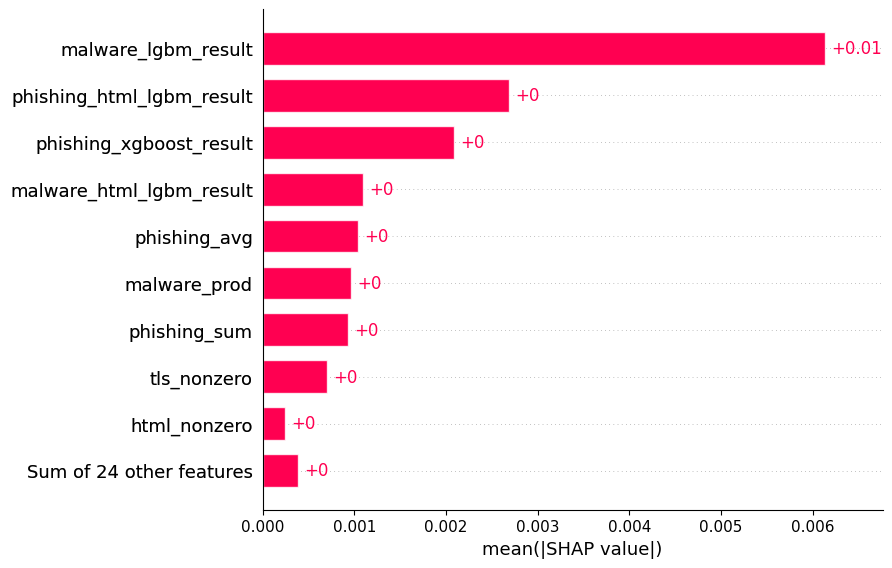

In [6]:
# Explain using SHAP
import shap
explainer = shap.Explainer(
    pipeline.clf_decision_nn.model,
    pipeline.clf_decision_nn.scaler.transform(suspicious[pipeline.clf_decision_nn.expected_features]),
    feature_names=pipeline.clf_decision_nn.expected_features
)
shap_values = explainer(pipeline.clf_decision_nn.scaler.transform(suspicious[pipeline.clf_decision_nn.expected_features]))
shap.plots.bar(shap_values)

In [7]:
suspicious[pipeline.clf_decision_nn.expected_features].describe().T[["mean", "std"]].sort_values("std")


,mean,std
dns_available,6.000000e-01,0.000000e+00
dns_nonzero,1.500000e-01,0.000000e+00
tls_available,1.000000e+00,0.000000e+00
html_available,1.000000e+00,0.000000e+00
ip_available,6.250000e-01,0.000000e+00
ip_nonzero,3.750000e-01,0.000000e+00
geo_nonzero,0.000000e+00,0.000000e+00
rdap_nonzero,2.500000e-01,0.000000e+00
geo_available,1.000000e+00,0.000000e+00
total_prod,2.902219e-19,2.928479e-19


## Suggested Fixes
1. Investigate over-sensitive features (based on SHAP).
2. Apply regularization or dropout in NN retraining.
3. Add synthetic samples with benign classifier outputs.
4. Possibly post-process decisions with heuristic thresholds.